## 1. Setup Dependencies

In this section we import all required libraries and initialize the main resources used throughout the notebook.

This includes:
- PyTorch for running the RoBERTa classifier
- VADER for sentiment analysis
- spaCy for named entity recognition
- OpenRouter, accessed through the OpenAI-compatible client, for the reasoning layer
- scikit-learn, matplotlib, and seaborn for evaluation and visualization

We also define the main configuration variables such as:
- the dataset split to use (`train`, `val`, or `test`)
- the maximum number of rows to sample
- the RoBERTa model name
- the OpenRouter model name

Finally, we load the API key from the `.env` file and initialize the NLP tools required by later sections.

In [2]:
# ============================================================
# TEXT-ONLY FAKE NEWS PIPELINE — AMG Dataset
# Structure:
# 1) Setup dependencies
# 2) Dataset loading
# 3) RoBERTa prediction layer
# 4) VADER + entity extraction
# 5) OpenRouter LLM reasoning layer
# 6) Evaluation
# ============================================================

# ============================================================
# 1. SETUP DEPENDENCIES
# ============================================================

import os
import re
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from dotenv import load_dotenv
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from openai import OpenAI
import spacy
from tqdm import tqdm

print("--- [1] Setup complete ---")

# ---------------- CONFIG ----------------
# Path to the Datasets folder (relative to this notebook)
AMG_DATASET_DIR = Path("../Datasets")
AMG_SPLIT       = "test"   # "train", "val", or "test"

MAX_ROWS     = 200   # set None to use the full split
RANDOM_STATE = 42

ROBERTA_MODEL_NAME = "hamzab/roberta-fake-news-classification"
OPENROUTER_MODEL   = "openai/gpt-4.1-mini"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load .env one level up from the notebook
load_dotenv(dotenv_path=Path("../.env"))
openrouter_api_key = os.getenv("OPENROUTER_API_KEY")
if not openrouter_api_key:
    raise ValueError(
        "Missing OPENROUTER_API_KEY environment variable. "
        "Set it in the .env file before running."
    )

client = OpenAI(
    api_key=openrouter_api_key,
    base_url="https://openrouter.ai/api/v1"
)

# ---------------- LOAD NLP TOOLS ----------------
tokenizer     = AutoTokenizer.from_pretrained(ROBERTA_MODEL_NAME)
roberta_model = AutoModelForSequenceClassification.from_pretrained(ROBERTA_MODEL_NAME)
roberta_model.to(device)
roberta_model.eval()

vader_analyzer = SentimentIntensityAnalyzer()

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    raise OSError(
        "spaCy model 'en_core_web_sm' is not installed.\n"
        "Run: python -m spacy download en_core_web_sm"
    )

C:\Users\anapa\anaconda3\envs\FakeNewsAP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- [1] Setup complete ---
Using device: cpu


Loading weights: 100%|██| 201/201 [00:00<00:00, 392.09it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: hamzab/roberta-fake-news-classification
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 2. Dataset Loading

Here we load the **AMG (Attribution Multi-Granularity)** dataset from the local `Datasets/` folder and prepare it for the text classification task.

The AMG dataset labels are:
- `0` → Real News
- `1` → Image Fabrication
- `2` → Entity Inconsistency
- `3` → Event Inconsistency
- `4` → Time & Space Inconsistency
- `5` → Ineffective Visual Information

For this **text-only** pipeline we collapse these into a **strict binary setup**:
- `0` (Real News) → **1** (Real)
- `1–5` (any fake type) → **0** (Fake)

In this section we also:
- keep the original row index for later inspection
- print the original AMG label counts
- apply the binary label mapping
- optionally sample a subset of rows for faster experimentation

In [4]:
# ============================================================
# 2. DATASET LOADING (AMG)
# ============================================================

print("--- [2] Dataset loading: AMG ---")

# AMG label names
AMG_LABEL_NAMES = {
    0: "real_news",
    1: "image_fabrication",
    2: "entity_inconsistency",
    3: "event_inconsistency",
    4: "time_space_inconsistency",
    5: "ineffective_visual_information",
}


def amg_label_name(x):
    try:
        return AMG_LABEL_NAMES.get(int(x), "unknown")
    except Exception:
        return "unknown"


def normalize_label_amg(label_value):
    """
    Binary mapping for text-only experiment:
      0        -> 1  (Real)
      1, 2, 3, 4, 5 -> 0  (Fake)
    """
    if pd.isna(label_value):
        return None
    try:
        x = int(label_value)
    except Exception:
        return None

    if x == 0:
        return 1   # Real
    if x in {1, 2, 3, 4, 5}:
        return 0   # Fake
    return None


# Load the chosen split
json_path = AMG_DATASET_DIR / f"{AMG_SPLIT}.json"
if not json_path.exists():
    raise FileNotFoundError(f"Dataset file not found: {json_path}")

with open(json_path, encoding="utf-8") as f:
    raw_data = json.load(f)

full_df = pd.DataFrame(raw_data)

# Keep original row index for later inspection
full_df = full_df.reset_index().rename(columns={"index": "orig_idx"})

# Show original label counts before any filtering
print(f"\nOriginal AMG label counts  (split = {AMG_SPLIT}):")
raw_counts = pd.to_numeric(full_df["label"], errors="coerce").dropna().astype(int).value_counts().sort_index()
for raw_label, count in raw_counts.items():
    print(f"  {raw_label} = {amg_label_name(raw_label):<32s} -> {count}")

# Build working dataframe
df = full_df[["orig_idx", "content", "label"]].copy()
df.columns = ["orig_idx", "text", "label_raw"]

df["text"]       = df["text"].astype(str).str.strip()
df["label_name"] = df["label_raw"].apply(amg_label_name)
df["label"]      = df["label_raw"].apply(normalize_label_amg)

# Remove empty / unmapped rows
df = df[(df["text"] != "") & (df["label"].notna())].reset_index(drop=True)

# Optional sample
if MAX_ROWS is not None:
    df = df.sample(min(MAX_ROWS, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)

samples = df.copy()

print(f"\nLoaded split  : {AMG_SPLIT}")
print(f"Rows used     : {len(samples)}")

print("\nRemaining original labels after filtering:")
print(samples["label_name"].value_counts())

print("\nFinal binary label distribution:")
print(samples["label"].value_counts().sort_index())   # 0=fake, 1=real

--- [2] Dataset loading: AMG ---

Original AMG label counts  (split = test):
  0 = real_news                        -> 576
  1 = image_fabrication                -> 76
  2 = entity_inconsistency             -> 29
  3 = event_inconsistency              -> 136
  4 = time_space_inconsistency         -> 91
  5 = ineffective_visual_information   -> 71

Loaded split  : test
Rows used     : 200

Remaining original labels after filtering:
label_name
real_news                         134
event_inconsistency                22
time_space_inconsistency           20
ineffective_visual_information     10
image_fabrication                   8
entity_inconsistency                6
Name: count, dtype: int64

Final binary label distribution:
label
0     66
1    134
Name: count, dtype: int64


In [5]:
pd.set_option('display.max_colwidth', None)
df.head(10)

,orig_idx,text,label_raw,label_name,label
0,940,Missing person,4,time_space_inconsistency,0
1,439,"Many of you may have seen my video about the black snake prophecy on Youtube, link below, and the movement at Standing Rock Indian Reservation with our water protectors. One may have thought the black snake was just one pipeline but it is actually many and is going to become a revolution to stop big oil from continuing their destruction of the planet and of us. Please watch this video and visit the site. \nWe need to come together and it is happening. Miracles are happening on levels we could never dream of. 2017 is going to bring with it the shift that begins to awaken the people in huge masses as we rise up and come together. \n https://youtu.be/UrKUzHtC3CE\n#BlackSnake #BlackSnakeProphecy #DefeatTheSnake #AwakenAndRiseUp #PsychicMedium",0,real_news,1
2,342,What Do You Do When You Suddenly Have $1 Billion? https://t.co/SwK9hwZbG4 https://t.co/Hj8pIHX55a,0,real_news,1
3,774,PELOSI’S Chief of staff = Chief of Excecutive of Dominion Ballot Counting Systems.,3,event_inconsistency,0
4,838,Mattel just released a new Barbie and some people are simply furious. Take a look and decide for yourself if it's worthy of the controversy. https://buff.ly/37wb1jp,3,event_inconsistency,0
5,898,"Trump rally - let’s see you’ve got your Nazi swastikas, Sieg Heil Hitler salute, individuals wrapped in both Confederate and Nazi flags. But I believe the pièce de résistance here has to be the massive painting of Trump as Jesus Christ their savior. These folks are just swell.",4,time_space_inconsistency,0
6,523,"אליס איילנד, ניו יורק, 12 ביוני 1936.\nאוטו ריכטר, יהודי גרמני ואשתו מפגינים נגד גירושו לגרמניה על ידי רשויות ההגירה האמריקאיות.\nעם הגעתו לניו יורק, אוטו לא הצליח לספק ניירות הגירה ""מתאימים"".\nבמקום להחזירו לגרמניה, בסוף אוטו ריכטר גורש למקסיקו.\n3 שנים לאחר הצילום הוא גורש לגרמניה שם מת ב-1939. יהי זכרו ברוך.\nלא ידעתי את זה! צילום: © SZ Photo / Scherl / Bridgeman Images.\nמקור: Is This a Photograph of European Jews Protesting Deportation",0,real_news,1
7,265,"Bankman-Fried, Claiming To Be Overwhelmed By Prosecution Evidence, Has Just Hours To Seek Trial Postponement https://t.co/v14GgFL0UJ https://t.co/VJjRcJYlFR",0,real_news,1
8,974,"""What will happen when the world looks away?"" An Afghan teacher on how the world can protect girls from the Taliban https://t.co/xL01bsEywy https://t.co/AdHUhDsKRP",0,real_news,1
9,540,"🇮🇷🇮🇱 The Black Flag has been raised over Razavi Shrine in Mashhad, Khorasan province, Iran.\t\tThis is a call for war or vengeance. https://t.co/jdbSUPByVB",3,event_inconsistency,0


In [6]:
df.shape

(200, 5)

## 3. RoBERTa Prediction Layer

This section applies the base **RoBERTa fake-news classifier** to each text statement.

For every input claim, the model returns:
- the predicted label (`fake` or `real`)
- the classifier confidence
- the fake-class probability
- the real-class probability

This classifier output is treated as the **main evidence signal** for the text agent and will later be passed to the LLM reasoning layer.

In [8]:
# ============================================================
# 3. ROBERTA PREDICTION LAYER
# ============================================================

print("--- [3] RoBERTa prediction layer ---")


def classify_with_roberta(text):
    """
    Returns:
      clf_prediction : 'fake' or 'real'
      clf_confidence : top softmax probability
      fake_score     : probability fake
      real_score     : probability real
    """
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256,
        padding=False
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = roberta_model(**inputs)
        probs   = F.softmax(outputs.logits, dim=1).squeeze()

    # index 0 -> fake  |  index 1 -> real
    fake_score = float(probs[0].item())
    real_score = float(probs[1].item())

    pred_idx   = int(torch.argmax(probs).item())
    label      = "fake" if pred_idx == 0 else "real"
    confidence = float(probs[pred_idx].item())

    return label, confidence, fake_score, real_score


samples[["clf_prediction", "clf_confidence", "fake_score", "real_score"]] = samples["text"].apply(
    lambda t: pd.Series(classify_with_roberta(t))
)

print("RoBERTa predictions done.")
print(samples["clf_prediction"].value_counts())

--- [3] RoBERTa prediction layer ---
RoBERTa predictions done.
clf_prediction
fake    160
real     40
Name: count, dtype: int64


## 4. VADER + Entity Extraction

In addition to the classifier output, we extract lightweight linguistic signals from the text.

First, we use **VADER** to compute:
- a sentiment label (`negative`, `neutral`, or `positive`)
- a compound sentiment score

Then, we use **spaCy named entity recognition** to extract entities such as:
- people
- organizations
- locations
- nationalities
- dates
- events

These signals do not verify whether a claim is true or false by themselves, but they provide useful context for the reasoning layer.

In [10]:
# ============================================================
# 4. PREPROCESSING + VADER + ENTITY EXTRACTION
# ============================================================

print("--- [4] Preprocessing + VADER + entity extraction ---")

import re


def preprocess_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", "", text)

    # Remove extra spaces/newlines/tabs
    text = re.sub(r"\s+", " ", text).strip()

    return text


def extract_vader_features(text):
    vs = vader_analyzer.polarity_scores(text)
    compound = float(vs["compound"])

    if compound < -0.05:
        sentiment_label = "negative"
    elif compound > 0.05:
        sentiment_label = "positive"
    else:
        sentiment_label = "neutral"

    return sentiment_label, compound


def extract_entities(text):
    doc = nlp(text)

    allowed_labels = {"PERSON", "ORG", "GPE", "NORP", "DATE", "EVENT"}
    ents = [(ent.text, ent.label_) for ent in doc.ents if ent.label_ in allowed_labels]

    entity_list = [f"{ent_text} ({ent_type})" for ent_text, ent_type in ents[:10]]
    entity_types = sorted(list(set(ent_type for _, ent_type in ents)))
    entity_count = len(ents)

    return entity_list, entity_types, entity_count


# Keep original text for comparison/debugging
samples["text_original"] = samples["text"]

# Apply preprocessing
samples["text"] = samples["text"].apply(preprocess_text)

# Optional: simple text length diagnostics
samples["char_count"] = samples["text"].apply(len)
samples["word_count"] = samples["text"].apply(lambda x: len(str(x).split()))

# VADER features
samples[["sentiment_label", "sentiment_compound"]] = samples["text"].apply(
    lambda t: pd.Series(extract_vader_features(t))
)

# Entity extraction
samples[["entities", "entity_types", "entity_count"]] = samples["text"].apply(
    lambda t: pd.Series(extract_entities(t))
)

print("Preprocessing + VADER + entity extraction done.")
print(samples[["text_original", "text", "word_count"]].head(5).to_string())

--- [4] Preprocessing + VADER + entity extraction ---
Preprocessing + VADER + entity extraction done.
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  text_original                                                                                                                                                   

## 5. OpenRouter LLM Reasoning Layer

In this section, we use an LLM through **OpenRouter** to interpret the evidence produced so far.

The LLM receives:
- the original text
- the RoBERTa prediction and confidence scores
- the VADER sentiment result
- the extracted entities

The prompt explicitly tells the LLM to:
- use only the provided evidence
- treat the classifier as the strongest signal
- use sentiment and entities only as weak supporting clues

This section produces:
- the raw LLM response
- the parsed decision (`real` / `fake`)
- the explanation
- the nudge (verification suggestion)

In [12]:
# ============================================================
# 5. OPENROUTER LLM REASONING LAYER
# ============================================================

print("--- [5] OpenRouter LLM reasoning layer ---")


def build_ampend_prompt(text, sentiment_label, sentiment_compound, entities, entity_types):
    entities_text      = ", ".join(entities)      if entities      else "None"
    entity_types_text  = ", ".join(entity_types)  if entity_types  else "None"

    return f"""You are an independent fact-checking assistant combining two roles:
1. A senior journalist analyzing rhetorical and persuasive framing
2. A logical analyst evaluating factual plausibility

Your task is to classify the following news post as Real or Fake.

NEWS POST:
\"{text}\"

AUXILIARY TEXT SIGNALS:
- Sentiment: {sentiment_label} (score: {sentiment_compound:.4f})
- Entity types: {entity_types_text}
- Entities mentioned: {entities_text}

Instructions:
1. You may use your internal world knowledge, but do not pretend you verified external sources in real time.
2. Consider whether the claim is factually plausible and whether it resembles a known hoax, satire pattern, or misleading framing.
3. Consider whether the wording relies on manipulation, hyperbole, fear, outrage, or sensationalism.
4. Do not classify a claim as Fake only because it is political, controversial, or emotionally charged.
5. You must output exactly one final label: Real or Fake.
6. Do not output uncertain, mixed, unknown, or maybe.
7. Even if evidence is incomplete, choose the more likely label.

Respond EXACTLY in this format:
- Decision: Real or Fake
- Explanation: 2 concise sentences
- Nudge: 1 practical suggestion for verification
""".strip()


def query_openrouter(prompt, model=OPENROUTER_MODEL, max_retries=3):
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model,
                temperature=0,
                max_tokens=200,
                messages=[
                    {
                        "role": "system",
                        "content": (
                            "You are an independent fact-checking assistant. "
                            "Provide concise, structured outputs."
                        )
                    },
                    {
                        "role": "user",
                        "content": prompt
                    }
                ]
            )
            return response.choices[0].message.content.strip()

        except Exception as e:
            print("OpenRouter API error:", repr(e))
            if attempt == max_retries - 1:
                return f"- Decision: Error\n- Explanation: API failed: {str(e)}\n- Nudge: None"
            time.sleep(2)


def parse_field(resp, key):
    match = re.search(rf"-\s*{key}\s*:\s*(.*)", str(resp), flags=re.IGNORECASE)
    return match.group(1).strip() if match else ""


def normalize_decision_text(d):
    d = str(d).strip().lower()
    if "fake" in d and "real" not in d:
        return "fake"
    if "real" in d and "fake" not in d:
        return "real"
    return None


# --- Quick single test before full loop ---
test_prompt = build_ampend_prompt(
    text             = samples.iloc[0]["text"],
    sentiment_label  = samples.iloc[0].get("sentiment_label",   "Neutral"),
    sentiment_compound = samples.iloc[0].get("sentiment_compound", 0.0),
    entities         = samples.iloc[0].get("entities",         []),
    entity_types     = samples.iloc[0].get("entity_types",     [])
)

print("\n--- OpenRouter test call ---")
test_response = query_openrouter(test_prompt)
print(test_response)


# --- Main execution loop ---
llm_responses = []

for _, row in tqdm(samples.iterrows(), total=len(samples), desc="Running Text Agent (AMG)"):
    prompt = build_ampend_prompt(
        text             = row["text"],
        sentiment_label  = row.get("sentiment_label",   "Neutral"),
        sentiment_compound = row.get("sentiment_compound", 0.0),
        entities         = row.get("entities",         []),
        entity_types     = row.get("entity_types",     [])
    )
    llm_responses.append(query_openrouter(prompt))

samples["llm_response"] = llm_responses

# Parse outputs
samples["llm_decision_raw"] = samples["llm_response"].map(lambda r: parse_field(r, "Decision"))
samples["llm_explanation"]  = samples["llm_response"].map(lambda r: parse_field(r, "Explanation"))
samples["llm_nudge"]        = samples["llm_response"].map(lambda r: parse_field(r, "Nudge"))
samples["llm_decision"]     = samples["llm_decision_raw"].apply(normalize_decision_text)

def llm_decision_to_int(x):
    if x == "fake": return 0
    if x == "real": return 1
    return None

samples["llm_label"] = samples["llm_decision"].apply(llm_decision_to_int)

print("\n--- LLM parsing check ---")
print(samples[["llm_decision_raw", "llm_decision", "llm_label"]].head(10))
print(samples["llm_decision"].value_counts(dropna=False))

--- [5] OpenRouter LLM reasoning layer ---

--- OpenRouter test call ---
- Decision: Real  
- Explanation: The phrase "Missing person" is a straightforward and plausible statement that does not exhibit sensationalism or manipulative framing. It aligns with common, factual reports of missing individuals without any exaggerated or misleading language.  
- Nudge: Verify by checking official police or local news reports for any recent missing person alerts.


Running Text Agent (AMG): 100%|████████████████████████████████████████████████████████████| 200/200 [05:30<00:00,  1.65s/it]


--- LLM parsing check ---
  llm_decision_raw llm_decision  llm_label
0             Real         real          1
1             Real         real          1
2             Real         real          1
3             Fake         fake          0
4             Real         real          1
5             Real         real          1
6             Real         real          1
7             Real         real          1
8             Real         real          1
9             Real         real          1
llm_decision
real    146
fake     54
Name: count, dtype: int64


## 6. Evaluation

This section compares the performance of:
- the base RoBERTa classifier
- the LLM-enhanced text agent

We compute:
- accuracy
- confusion matrices
- classification reports
- LLM coverage

The goal is to determine whether the reasoning layer provides an improvement over the classifier alone.

In [14]:
print(samples[["llm_decision_raw", "llm_label"]].head(10))
print(samples["llm_label"].value_counts(dropna=False))

  llm_decision_raw  llm_label
0             Real          1
1             Real          1
2             Real          1
3             Fake          0
4             Real          1
5             Real          1
6             Real          1
7             Real          1
8             Real          1
9             Real          1
llm_label
1    146
0     54
Name: count, dtype: int64


In [37]:
print(samples[["text_original", "text"]].head(3).to_string())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  text_original                                                                                                                                                                                                                                                         

--- [6] Evaluation ---
RoBERTa Accuracy : 0.460
LLM Accuracy     : 0.780
LLM Coverage     : 1.000

RoBERTa Confusion Matrix:
 [[ 59   7]
 [101  33]]

LLM Confusion Matrix:
 [[ 38  28]
 [ 16 118]]

-----------------------------------------------------
RoBERTa Classification Report
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.37      0.89      0.52        66
        Real       0.82      0.25      0.38       134

    accuracy                           0.46       200
   macro avg       0.60      0.57      0.45       200
weighted avg       0.67      0.46      0.43       200


-----------------------------------------------------
LLM Classification Report
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.70      0.58      0.63        66
        Real       0.81      0.88      0.84       134

    accuracy                           

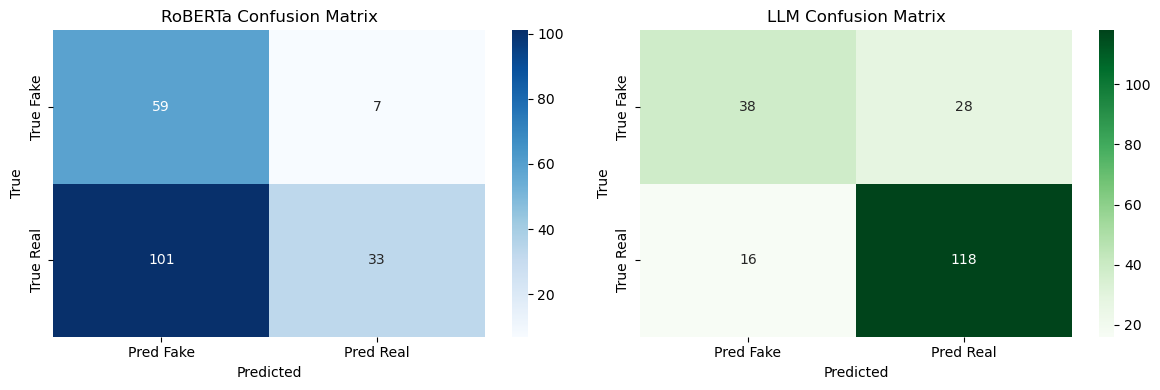

>>> Text-only pipeline (AMG) complete.


In [15]:
# ============================================================
# 6. EVALUATION
# ============================================================

print("--- [6] Evaluation ---")


def label_to_int(x):
    x = str(x).strip().lower()
    if x == "fake": return 0
    if x == "real": return 1
    return None


# Ground truth
samples["true_label"] = samples["label"].astype(int)

# RoBERTa branch
samples["clf_label"] = samples["clf_prediction"].apply(label_to_int)

# Keep only rows with valid LLM outputs
llm_clean = samples.dropna(subset=["llm_label"]).copy()
llm_clean["llm_label"] = llm_clean["llm_label"].astype(int)

# Metrics
clf_acc = accuracy_score(samples["true_label"], samples["clf_label"])
llm_acc = accuracy_score(llm_clean["true_label"], llm_clean["llm_label"]) if len(llm_clean) > 0 else float("nan")
llm_cov = len(llm_clean) / len(samples) if len(samples) > 0 else 0.0

print(f"RoBERTa Accuracy : {clf_acc:.3f}")
print(f"LLM Accuracy     : {llm_acc:.3f}" if len(llm_clean) > 0 else "LLM Accuracy: nan")
print(f"LLM Coverage     : {llm_cov:.3f}")

# Confusion matrices
clf_cm = confusion_matrix(samples["true_label"], samples["clf_label"])
print("\nRoBERTa Confusion Matrix:\n", clf_cm)

if len(llm_clean) > 0:
    llm_cm = confusion_matrix(llm_clean["true_label"], llm_clean["llm_label"])
    print("\nLLM Confusion Matrix:\n", llm_cm)

# Classification reports
print("\n-----------------------------------------------------")
print("RoBERTa Classification Report")
print("-----------------------------------------------------")
print(classification_report(samples["true_label"], samples["clf_label"], target_names=["Fake", "Real"]))

if len(llm_clean) > 0:
    print("\n-----------------------------------------------------")
    print("LLM Classification Report")
    print("-----------------------------------------------------")
    print(classification_report(llm_clean["true_label"], llm_clean["llm_label"], target_names=["Fake", "Real"]))

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(
    clf_cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred Fake", "Pred Real"],
    yticklabels=["True Fake", "True Real"],
    ax=axes[0]
)
axes[0].set_title("RoBERTa Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

if len(llm_clean) > 0:
    sns.heatmap(
        llm_cm, annot=True, fmt="d", cmap="Greens",
        xticklabels=["Pred Fake", "Pred Real"],
        yticklabels=["True Fake", "True Real"],
        ax=axes[1]
    )
    axes[1].set_title("LLM Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
else:
    axes[1].axis("off")
    axes[1].set_title("LLM Confusion Matrix unavailable")

plt.tight_layout()
plt.show()

print(">>> Text-only pipeline (AMG) complete.")

## 7. Dataset Inspection + Example Rows

After running the main pipeline, this section is used to inspect the processed dataset.

We print:
- the dataframe shape
- the column names
- the first rows
- the label distribution
- missing-value counts
- text-length statistics

This helps verify that the dataset was loaded correctly and that all intermediate outputs were generated as expected.

In [17]:
# ============================================================
# DATASET INSPECTION + EXAMPLE ROWS
# ============================================================

print("--- Dataset quick inspection ---")

print("Shape:", samples.shape)

print("\nColumns:")
print(samples.columns.tolist())

print("\nFirst 5 rows:")
print(samples.head())

--- Dataset quick inspection ---
Shape: (200, 25)

Columns:
['orig_idx', 'text', 'label_raw', 'label_name', 'label', 'clf_prediction', 'clf_confidence', 'fake_score', 'real_score', 'text_original', 'char_count', 'word_count', 'sentiment_label', 'sentiment_compound', 'entities', 'entity_types', 'entity_count', 'llm_response', 'llm_decision_raw', 'llm_explanation', 'llm_nudge', 'llm_decision', 'llm_label', 'true_label', 'clf_label']

First 5 rows:
   orig_idx  \
0       940   
1       439   
2       342   
3       774   
4       838   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [18]:
# Label distribution
print("\nOriginal AMG label distribution (in sample):")
if "label_name" in samples.columns:
    print(samples["label_name"].value_counts(dropna=False))

print("\nBinary label distribution:")
if "label" in samples.columns:
    print(samples["label"].value_counts(dropna=False).sort_index())   # 0=fake, 1=real

# Missing values
print("\nMissing values per column:")
print(samples.isnull().sum())

# Text length statistics
samples["char_len"] = samples["text"].astype(str).apply(len)
samples["word_len"] = samples["text"].astype(str).apply(lambda x: len(x.split()))

print("\nText length stats (characters):")
print(samples["char_len"].describe())

print("\nText length stats (words):")
print(samples["word_len"].describe())


Original AMG label distribution (in sample):
label_name
real_news                         134
event_inconsistency                22
time_space_inconsistency           20
ineffective_visual_information     10
image_fabrication                   8
entity_inconsistency                6
Name: count, dtype: int64

Binary label distribution:
label
0     66
1    134
Name: count, dtype: int64

Missing values per column:
orig_idx              0
text                  0
label_raw             0
label_name            0
label                 0
clf_prediction        0
clf_confidence        0
fake_score            0
real_score            0
text_original         0
char_count            0
word_count            0
sentiment_label       0
sentiment_compound    0
entities              0
entity_types          0
entity_count          0
llm_response          0
llm_decision_raw      0
llm_explanation       0
llm_nudge             0
llm_decision          0
llm_label             0
true_label            0
clf_lab

## 8. Error Analysis

This section breaks the results into three groups:

1. RoBERTa correct, LLM wrong
2. RoBERTa wrong, LLM correct
3. Both wrong

For each case, we print:
- the text
- the true label
- the RoBERTa prediction and confidence
- the LLM decision
- the sentiment output
- the extracted entities
- the LLM explanation

This helps us understand when the LLM is helpful, when it hurts performance, and where each component struggles.

In [20]:
# RoBERTa correct, LLM wrong
case1 = samples[(samples["clf_label"] == samples["true_label"]) & (samples["llm_label"] != samples["true_label"])]

# RoBERTa wrong, LLM correct
case2 = samples[(samples["clf_label"] != samples["true_label"]) & (samples["llm_label"] == samples["true_label"])]

# Both wrong
case3 = samples[(samples["clf_label"] != samples["true_label"]) & (samples["llm_label"] != samples["true_label"])]

for name, df_case in [("RoBERTa correct, LLM wrong", case1),
                      ("RoBERTa wrong, LLM correct", case2),
                      ("Both wrong",                 case3)]:
    print(f"\n===== {name} ({len(df_case)} rows) =====")
    subset = df_case.head(5)
    for i, (_, row) in enumerate(subset.iterrows(), 1):
        print(f"\nExample {i}")
        print("-" * 70)
        print("Text:",        row["text"])
        print("True label:",  row["true_label"], "(", amg_label_name(row["label_raw"]), ")")
        print("RoBERTa:",     row["clf_prediction"], "| conf:", row["clf_confidence"])
        print("LLM:",         row["llm_decision"])
        print("Sentiment:",   row["sentiment_label"], row["sentiment_compound"])
        print("Entities:",    row["entities"])
        print("LLM explanation:", row["llm_explanation"])


===== RoBERTa correct, LLM wrong (28 rows) =====

Example 1
----------------------------------------------------------------------
Text: Missing person
True label: 0 ( time_space_inconsistency )
RoBERTa: fake | conf: 0.997017502784729
LLM: real
Sentiment: negative -0.296
Entities: []
LLM explanation: The phrase "Missing person" is a straightforward and plausible statement commonly used in genuine reports. There is no indication of manipulation, sensationalism, or known hoax patterns in this minimal text.

Example 2
----------------------------------------------------------------------
Text: Mattel just released a new Barbie and some people are simply furious. Take a look and decide for yourself if it's worthy of the controversy.
True label: 0 ( event_inconsistency )
RoBERTa: fake | conf: 0.9998401403427124
LLM: real
Sentiment: negative -0.2023
Entities: ['Mattel (ORG)', 'Barbie (PERSON)']
LLM explanation: Mattel frequently releases new Barbie dolls that sometimes spark public debate, 

In [21]:
print(samples["llm_decision_raw"].value_counts(dropna=False))

llm_decision_raw
Real    146
Fake     54
Name: count, dtype: int64


In [22]:
llm_false_positives_real = samples[
    (samples["true_label"] == 0) &   # actually Fake
    (samples["llm_label"]  == 1)     # predicted Real
]

print(llm_false_positives_real[["text", "true_label", "llm_label", "llm_explanation"]].head(20).to_string())

                                                                                                                                                                                                                                                                                                                                                                                                          text  true_label  llm_label                                                                                                                                                                                                                                                                                                                             llm_explanation
0                                                                                                                                                                                                                                                     